# GrIS elevation zone melt SEB causality

Author: Ziqi Yin

Last modified: 2026 Feb 27

Description: comparing causal graphs from CESM2 LENS2 during the historical period (1975-2014) and the future scenario (2061-2100) over different elevation zones.

In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

import cartopy
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PolyCollection
from collections import Counter, defaultdict

In [4]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

## Read data

### Causal graph

In [5]:
val_matrix_LENS2_his = []
graph_LENS2_his = []
link_width_LENS2_his = []

val_matrix_LENS2_end = []
graph_LENS2_end = []
link_width_LENS2_end = []

In [7]:
## Set parameters
max_lag = 12
boot_blocklength = 12
pc_alpha = 0.05
elev_names = ['lt1000', 'ht1000lt2000', 'lt2000']

In [8]:
for elev in elev_names:

    # LENS2
    data_dir = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_elev'+elev+'_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'
    data = np.load(data_dir, allow_pickle=True)
    val_matrix_LENS2_his.append(data['val_matrix'])
    graph_LENS2_his.append(data['graph'])
    link_width_LENS2_his.append(data['link_width'])

    data_dir = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_elev'+elev+'_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'
    data = np.load(data_dir, allow_pickle=True)
    val_matrix_LENS2_end.append(data['val_matrix'])
    graph_LENS2_end.append(data['graph'])
    link_width_LENS2_end.append(data['link_width'])

In [12]:
## Elevation
data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1/'
PHIS = xr.open_dataset(data_dir+'PHIS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.PHIS.197001-197912.nc')['PHIS'][0]

data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/lnd/proc/tseries/month_1/'
f09_lnd_lon = xr.open_dataset(data_dir+'SNOW/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.SNOW.197001-197912.nc')['SNOW'].lon
f09_lnd_lat = xr.open_dataset(data_dir+'SNOW/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.SNOW.197001-197912.nc')['SNOW'].lat

PHIS['lon'] = f09_lnd_lon.values
PHIS['lat'] = f09_lnd_lat.values

g = 9.80616 #[m/s2]

In [26]:
## SMB
smb_mean = xr.open_dataset(home_dir+'2023-GrIS-melt-causality/data/LENS2/smb_ICE_yearly_mean_1975_2014_ensmean.nc')['SMB']

In [36]:
## Mask
# Generate Greenland mask
f09_mask_file1 = '/glade/work/aherring/grids/uniform-res/f09/clm_surfdata_5_0/surfdata_f09_hist_78pfts_CMIP6_simyr1850_c200429.nc'
f09_GrIS_mask0 = xr.open_dataset(f09_mask_file1)['GLACIER_REGION']
f09_GrIS_mask0 = xr.where(f09_GrIS_mask0==2, 1, np.nan)

# Land fraction of grid cell
f09_mask_file3 = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001/lnd/proc/tseries/month_1/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001.clm2.h0.RAIN.000101-005012.nc'
f09_land_frac = xr.open_dataset(f09_mask_file3)['landfrac'] #fraction of grid cell that is active

# Ice fraction
data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/lnd/proc/tseries/month_1/'
f09_glacier_frac = xr.open_dataset(data_dir+'PCT_LANDUNIT/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.PCT_LANDUNIT.197001-197912.nc')['PCT_LANDUNIT'][0,3,:,:]

# GrIS mask
f09_GrIS_mask = f09_GrIS_mask0.values * f09_glacier_frac * f09_land_frac.values / 100

## Plot

In [9]:
def tp_plot_graph(val_matrix, graph, link_width, show_colorbar, i):

    tp.plot_graph(
        val_matrix=val_matrix,
        graph=graph,
        var_names=['Melt', 'SWn', 'LWn', 'SH', 'LH'],
        link_width=link_width,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        #lagged_links=True  # This setting allows multiple links for different lags to be displayed
        show_colorbar=show_colorbar,
        fig_ax=(fig, axs[i])
    )

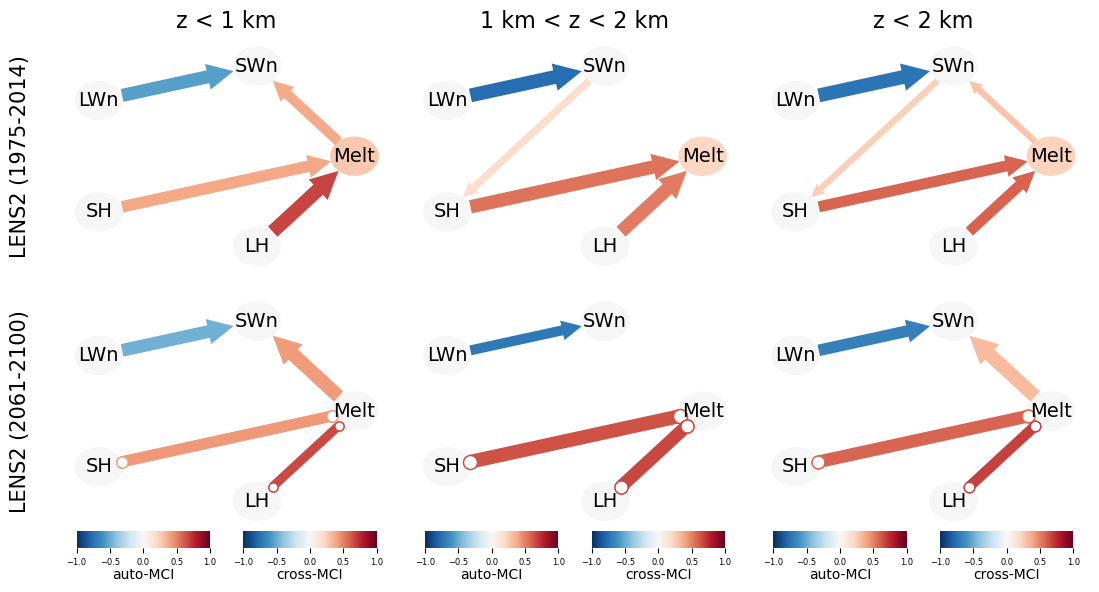

In [10]:
##
fig, axs = plt.subplots(2, 3, figsize=(11, 6))
axs = axs.flatten()  # Flatten to easily index subplots

for n in range(3):
    tp_plot_graph(val_matrix_LENS2_his[n], graph_LENS2_his[n], link_width_LENS2_his[n], False, n)
    tp_plot_graph(val_matrix_LENS2_end[n], graph_LENS2_end[n], link_width_LENS2_end[n], True, n+3)


# Add significance level
size_title = 16
axs[0].set_title("z < 1 km", fontsize=size_title)
axs[1].set_title("1 km < z < 2 km", fontsize=size_title)
axs[2].set_title("z < 2 km", fontsize=size_title)

# Add model name
axs[0].text(-0.12, 0.5, "LENS2 (1975-2014)", rotation=90,
           transform=axs[0].transAxes,
           ha='center', va='center',
           fontsize=size_title-1)
axs[3].text(-0.12, 0.5, "LENS2 (2061-2100)", rotation=90,
           transform=axs[3].transAxes,
           ha='center', va='center',
           fontsize=size_title-1)

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/manuscript/revision1/'
plt.savefig(plot_dir+'figS8_causal_graph_ICE_monthly_1975_2014_conservative_nofdrc_robustparcorr_taumax12_elev_nomask.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

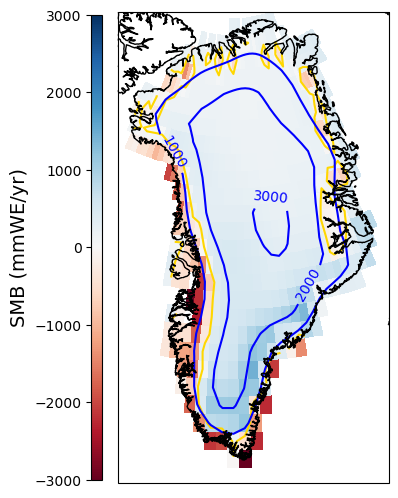

In [43]:
# Plot the ablation mask for the first ensemble member
fig = plt.figure(figsize = (3.5,6.2))
gs=GridSpec(1,1)
plt.rcParams['axes.titlepad'] =14

#---------------------------------------------1----------------------------------------------------
ax1 = plt.subplot(gs[0], projection=polar_stereographic)
ax1.set_extent([-56.4, -29.6, 58, 84])
ax1.coastlines(resolution='10m', zorder=7)

im1 = ax1.pcolormesh(f09_lnd_lon, f09_lnd_lat, (smb_mean*(365*24*3600)).where(f09_GrIS_mask>0), cmap='RdBu', vmin=-3000, vmax=3000, transform=ccrs.PlateCarree())
im2 = ax1.contour(f09_lnd_lon, f09_lnd_lat, (smb_mean*(365*24*3600)).where(f09_GrIS_mask>0), [0], colors=['gold'], transform=ccrs.PlateCarree())
im3 = ax1.contour(f09_lnd_lon, f09_lnd_lat, PHIS/g, [1000, 2000, 3000, 4000], colors=['b'], transform=ccrs.PlateCarree())
ax1.clabel(im3, fontsize=10)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# colorbar
cbar_ax1 = fig.add_axes([0.05, 0.121, 0.03, 0.75])
cb1 = fig.colorbar(im1, cax=cbar_ax1, orientation='vertical')
cb1.ax.yaxis.set_ticks_position('left')
cb1.ax.yaxis.set_label_position('left')
cb1.set_label('SMB (mmWE/yr)', size=14)
cb1.ax.tick_params(labelsize=10)


plt.subplots_adjust(wspace=0.2)
plt.savefig('map_SMB_elev_ICE_LENS2_1975_2014.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)